In [195]:
# ==============================
# CELL 1: Imports
# ==============================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import time

In [196]:
# ==============================
# CELL 2: Load Data
# ==============================

base_path = r"C:\Users\mayan\Desktop\3STSEM\ai\model\Datasets"

tasks = pd.read_csv(os.path.join(base_path, "dataset_A.csv"))
edge_nodes = pd.read_csv(os.path.join(base_path, "edge_nodes.csv"))
edge_state = pd.read_csv(os.path.join(base_path, "edge_state.csv"))
cloud_nodes = pd.read_csv(os.path.join(base_path, "cloud_nodes.csv"))
cloud_state = pd.read_csv(os.path.join(base_path, "cloud_state.csv"))
network_state = pd.read_csv(os.path.join(base_path, "network_state.csv"))

print("Tasks shape:", tasks.shape)

Tasks shape: (100000, 11)


In [197]:
# Add Task Types
task_types = ["sensor", "image", "ai", "video"]

tasks["task_type"] = np.random.choice(
    task_types,
    size=len(tasks),
    p=[0.5, 0.25, 0.15, 0.10]
)

tasks.loc[tasks["task_type"]=="sensor", "cpu_cycles"] *= 0.5
tasks.loc[tasks["task_type"]=="image", "cpu_cycles"] *= 1.5
tasks.loc[tasks["task_type"]=="ai", "cpu_cycles"] *= 3
tasks.loc[tasks["task_type"]=="video", "cpu_cycles"] *= 2
network_state["load_factor"] = 1 + 0.5 * np.sin(
    2 * np.pi * network_state["timestep"] / 200
)

network_state["network_delay_ms"] *= network_state["load_factor"]
for idx, row in network_state.iterrows():
    if row["network_delay_ms"] > 70:
        edge_state.loc[
            edge_state["timestep"] == row["timestep"],
            "edge_queue_length"
        ] += np.random.randint(5,15)

In [198]:
# ==============================
# CELL 3: Latency Engine
# ==============================

def compute_latency(task_row):
    
    t = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]
    
    edge = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"] == edge_id)
    ].iloc[0]
    
    net = network_state[
        network_state["timestep"] == t
    ].iloc[0]
    
    cloud_t = cloud_state[
        cloud_state["timestep"] == t
    ]
    
    cloud_cpu = cloud_t["cloud_cpu_available"].mean()
    cloud_queue = cloud_t["cloud_queue_length"].mean()
    
    # Edge latency
    edge_latency = (
        task_row["cpu_cycles"] / edge["edge_cpu_available"]
        + edge["edge_queue_length"] * 0.5
    )
    
    # Cloud latency
    cloud_latency = (
        task_row["task_size_mb"] / net["uplink_bandwidth"]
        + task_row["cpu_cycles"] / cloud_cpu
        + net["network_delay_ms"]
        + cloud_queue * 0.5
    )
    
    return 0 if edge_latency < cloud_latency else 1



In [199]:
# ==============================
# CELL 4: Generate Labels
# ==============================

print("Generating offloading labels...")
tasks["offload_label"] = tasks.apply(compute_latency, axis=1)

print(tasks["offload_label"].value_counts())

Generating offloading labels...
offload_label
0    91778
1     8222
Name: count, dtype: int64


In [200]:
# ==============================
# CELL 5: Feature Engineering
# ==============================

def build_features(task_row):
    
    t = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]
    
    edge = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"] == edge_id)
    ].iloc[0]
    
    net = network_state[
        network_state["timestep"] == t
    ].iloc[0]
    
    cloud_t = cloud_state[
        cloud_state["timestep"] == t
    ]
    
    return [
        task_row["task_size_mb"],
        task_row["cpu_cycles"],
        task_row["memory_req_mb"],
        task_row["deadline_ms"],
        task_row["priority_level"],
        task_row["security_sensitivity"],
        edge["edge_cpu_available"],
        edge["edge_memory_available"],
        edge["edge_queue_length"],
        net["network_delay_ms"],
        net["uplink_bandwidth"],
        cloud_t["cloud_cpu_available"].mean(),
        cloud_t["cloud_queue_length"].mean()
    ]

features = np.array(tasks.apply(build_features, axis=1).tolist())
labels = tasks["offload_label"].values

print("Feature shape:", features.shape)

Feature shape: (100000, 13)


In [201]:
# Required imports for preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:
# ==============================
# CELL 6: Time-Based Train/Test Split
# ==============================

# Define cutoff time
cutoff_time = 700

# Split tasks based on arrival_time
train_mask = tasks["arrival_time"] <= cutoff_time
test_mask  = tasks["arrival_time"] > cutoff_time

X_train = features[train_mask]
X_test  = features[test_mask]

y_train = labels[train_mask]
y_test  = labels[test_mask]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))
# ==============================
# CELL 7: Proper Scaling
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to Torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.squeeze(), dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.squeeze(), dtype=torch.long)

Train samples: 97028
Test samples : 2972


In [ ]:
# ==============================
# CELL 7: Offloading Model
# ==============================

class OffloadNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        return self.layers(x)

model = OffloadNet(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# ==============================
# CELL 8: Federated Setup
# ==============================

def split_clients(X, y, num_clients=5):
    split_size = len(X) // num_clients
    clients = []
    for i in range(num_clients):
        start = i * split_size
        end = (i + 1) * split_size
        clients.append((X[start:end], y[start:end]))
    return clients

clients = split_clients(X_train, y_train, num_clients=5)

In [205]:
# ==============================
# CELL 9: Federated Training
# ==============================

def federated_average(models):
    global_model = deepcopy(models[0])
    for key in global_model.state_dict().keys():
        global_model.state_dict()[key] = torch.mean(
            torch.stack([m.state_dict()[key].float() for m in models]), dim=0
        )
    return global_model

rounds = 20

for r in range(rounds):
    local_models = []
    
    for client_X, client_y in clients:
        local_model = deepcopy(model)
        opt = optim.Adam(local_model.parameters(), lr=0.001)
        
        for epoch in range(2):
            opt.zero_grad()
            output = local_model(client_X)
            loss = criterion(output, client_y)
            loss.backward()
            opt.step()
        
        local_models.append(local_model)
    
    model = federated_average(local_models)
    print(f"Federated Round {r+1} completed")

Federated Round 1 completed
Federated Round 2 completed
Federated Round 3 completed
Federated Round 4 completed
Federated Round 5 completed
Federated Round 6 completed
Federated Round 7 completed
Federated Round 8 completed
Federated Round 9 completed
Federated Round 10 completed
Federated Round 11 completed
Federated Round 12 completed
Federated Round 13 completed
Federated Round 14 completed
Federated Round 15 completed
Federated Round 16 completed
Federated Round 17 completed
Federated Round 18 completed
Federated Round 19 completed
Federated Round 20 completed


In [206]:
# ==============================
# CELL 10: Evaluation
# ==============================

with torch.no_grad():
    start = time.time()
    predictions = model(X_test)
    decision_time = time.time() - start
    
    predicted = torch.argmax(predictions, dim=1)
    accuracy = (predicted == y_test).float().mean()

print("Test Accuracy:", accuracy.item())
print("Decision Overhead Time:", decision_time)

Test Accuracy: 0.9717361927032471
Decision Overhead Time: 0.0021469593048095703


In [207]:
# ==============================
# CELL 11: Resource Allocation Model
# ==============================

class ResourceAllocator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # CPU share, Memory share
        )
    
    def forward(self, x):
        return self.layers(x)

allocator = ResourceAllocator(X_train.shape[1])

In [208]:
# ==============================
# CELL 12: Generate Allocation Targets
# ==============================

def generate_allocation_targets(task_row):
    
    t = task_row["arrival_time"]
    edge_id = task_row["assigned_edge_id"]
    
    edge = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"] == edge_id)
    ].iloc[0]
    
    # CPU share proportional to demand
    cpu_share = task_row["cpu_cycles"] / edge["edge_cpu_available"]
    cpu_share = np.clip(cpu_share, 0.01, 1.0)
    
    # Memory share proportional to demand
    mem_share = task_row["memory_req_mb"] / edge["edge_memory_available"]
    mem_share = np.clip(mem_share, 0.01, 1.0)
    
    return [cpu_share, mem_share]

allocation_targets = np.array(tasks.apply(generate_allocation_targets, axis=1).tolist())

In [209]:
# ==============================
# CELL 13: Filter Edge Tasks
# ==============================

edge_mask = tasks["offload_label"] == 0

X_alloc = features[edge_mask]
y_alloc = allocation_targets[edge_mask]

X_alloc = torch.tensor(X_alloc, dtype=torch.float32)
y_alloc = torch.tensor(y_alloc, dtype=torch.float32)

print("Edge allocation samples:", X_alloc.shape)

Edge allocation samples: torch.Size([91778, 13])


In [210]:
# ==============================
# CELL 14: Resource Allocation Model
# ==============================

class ResourceAllocator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Sigmoid()  # Output between 0 and 1
        )
    
    def forward(self, x):
        return self.layers(x)

allocator = ResourceAllocator(X_alloc.shape[1])
criterion_alloc = nn.MSELoss()
optimizer_alloc = optim.Adam(allocator.parameters(), lr=0.001)

In [211]:
# ==============================
# CELL 15: Train Allocation Model
# ==============================

epochs = 15

for epoch in range(epochs):
    optimizer_alloc.zero_grad()
    outputs = allocator(X_alloc)
    loss = criterion_alloc(outputs, y_alloc)
    loss.backward()
    optimizer_alloc.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1426
Epoch 2, Loss: 0.1383
Epoch 3, Loss: 0.1344
Epoch 4, Loss: 0.1307
Epoch 5, Loss: 0.1273
Epoch 6, Loss: 0.1240
Epoch 7, Loss: 0.1210
Epoch 8, Loss: 0.1182
Epoch 9, Loss: 0.1156
Epoch 10, Loss: 0.1133
Epoch 11, Loss: 0.1111
Epoch 12, Loss: 0.1092
Epoch 13, Loss: 0.1075
Epoch 14, Loss: 0.1059
Epoch 15, Loss: 0.1046


In [212]:
# ==============================
# CELL 16: Evaluate Allocation
# ==============================

with torch.no_grad():
    preds = allocator(X_alloc)
    error = torch.mean(torch.abs(preds - y_alloc))
    
print("Mean Allocation Error:", error.item())

Mean Allocation Error: 0.2901361882686615


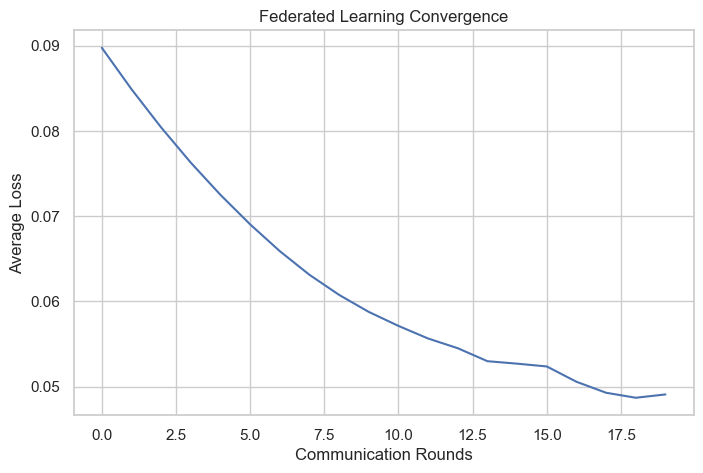

In [213]:
# ==============================
# Federated Convergence Plot
# ==============================
import matplotlib.pyplot as plt
federated_losses = []

for r in range(rounds):
    local_losses = []
    local_models = []
    
    for client_X, client_y in clients:
        local_model = deepcopy(model)
        opt = optim.Adam(local_model.parameters(), lr=0.001)
        
        for epoch in range(2):
            opt.zero_grad()
            output = local_model(client_X)
            loss = criterion(output, client_y)
            loss.backward()
            opt.step()
        
        local_losses.append(loss.item())
        local_models.append(local_model)
    
    model = federated_average(local_models)
    federated_losses.append(np.mean(local_losses))

plt.plot(federated_losses)
plt.title("Federated Learning Convergence")
plt.xlabel("Communication Rounds")
plt.ylabel("Average Loss")
plt.show()

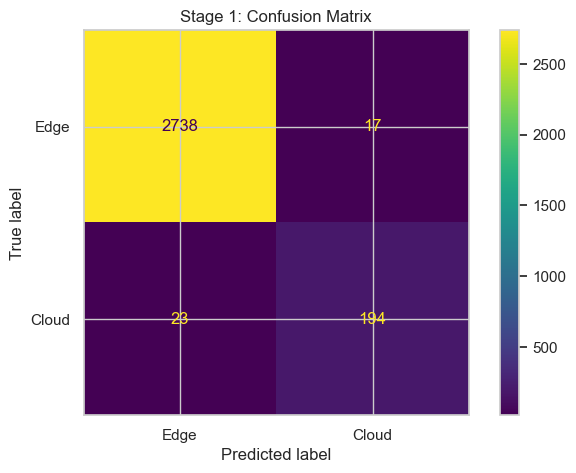

In [214]:
# ==============================
# Stage 1: Confusion Matrix
# ==============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

with torch.no_grad():
    preds = model(X_test)
    pred_labels = torch.argmax(preds, dim=1).numpy()

cm = confusion_matrix(y_test.numpy(), pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Edge","Cloud"])

disp.plot()
plt.title("Stage 1: Confusion Matrix")
plt.show()

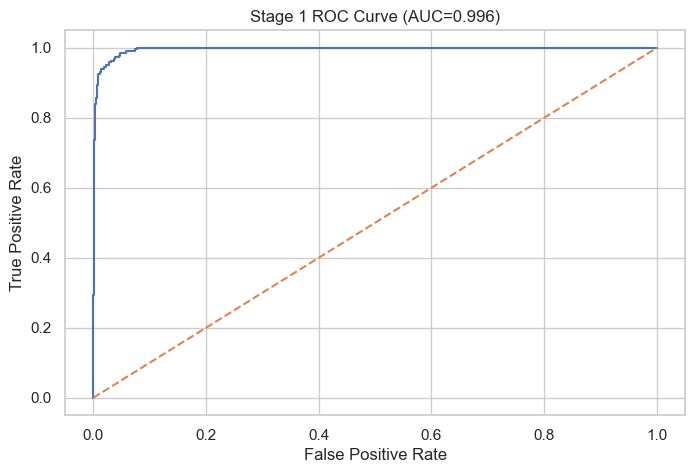

In [215]:
# ==============================
# Stage 1: ROC Curve
# ==============================

from sklearn.metrics import roc_curve, auc

with torch.no_grad():
    probs = torch.softmax(model(X_test), dim=1)[:,1].numpy()

fpr, tpr, _ = roc_curve(y_test.numpy(), probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"Stage 1 ROC Curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

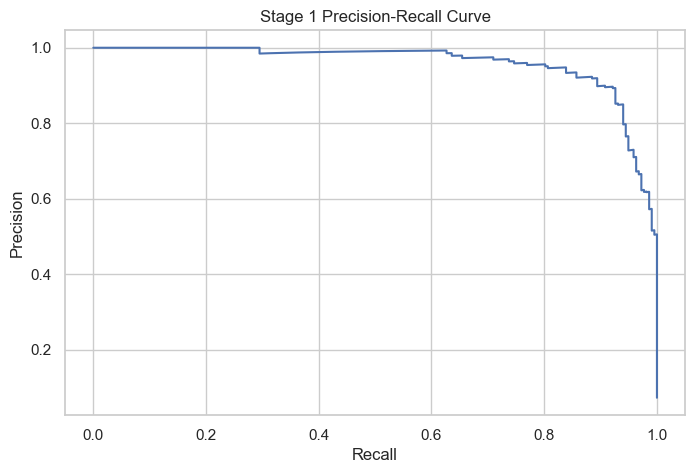

In [216]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test.numpy(), probs)

plt.plot(recall, precision)
plt.title("Stage 1 Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

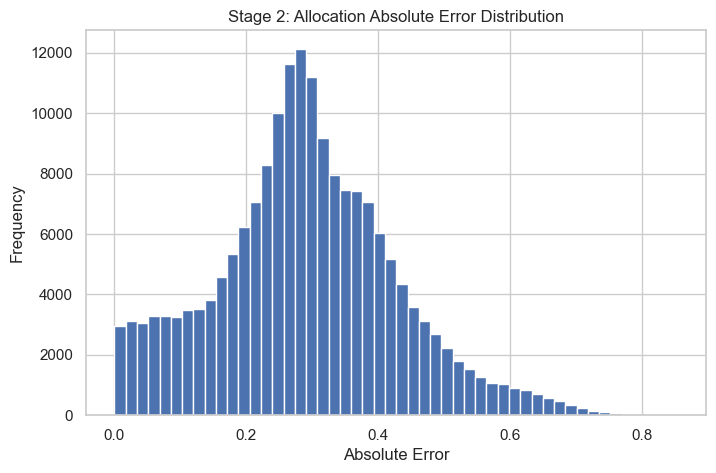

In [217]:
# ==============================
# Stage 2: Allocation Error Histogram
# ==============================

with torch.no_grad():
    alloc_preds = allocator(X_alloc)
    errors = torch.abs(alloc_preds - y_alloc).numpy()

plt.hist(errors.flatten(), bins=50)
plt.title("Stage 2: Allocation Absolute Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.show()

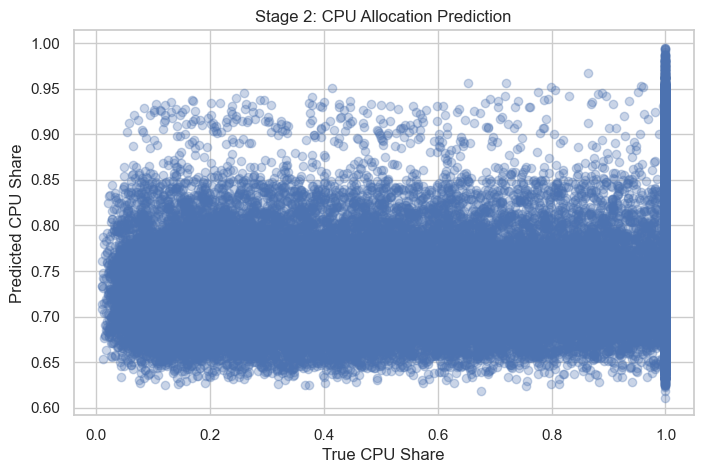

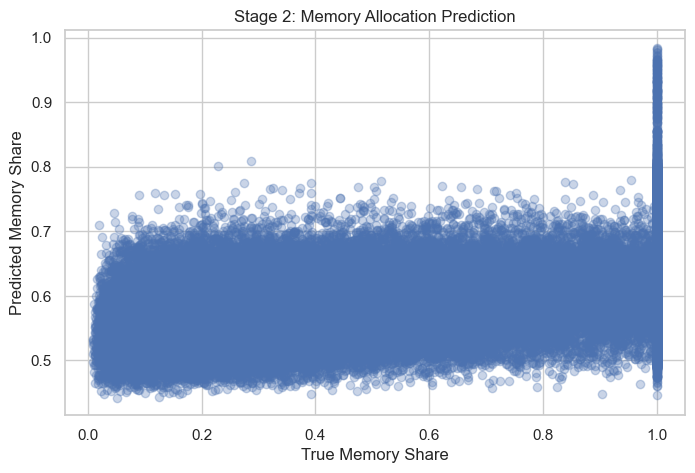

In [218]:
# CPU Allocation Scatter
plt.scatter(y_alloc[:,0], alloc_preds[:,0], alpha=0.3)
plt.title("Stage 2: CPU Allocation Prediction")
plt.xlabel("True CPU Share")
plt.ylabel("Predicted CPU Share")
plt.show()

# Memory Allocation Scatter
plt.scatter(y_alloc[:,1], alloc_preds[:,1], alpha=0.3)
plt.title("Stage 2: Memory Allocation Prediction")
plt.xlabel("True Memory Share")
plt.ylabel("Predicted Memory Share")
plt.show()

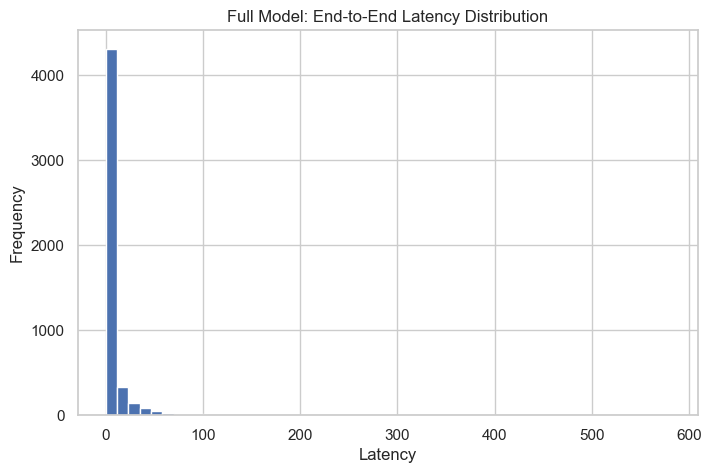

In [219]:
# ==============================
# Full Model: End-to-End Latency
# ==============================

end_to_end_latency = []

sample = tasks.sample(5000)

for _, row in sample.iterrows():
    
    t = row["arrival_time"]
    edge_id = row["assigned_edge_id"]
    
    edge = edge_state[
        (edge_state["timestep"] == t) &
        (edge_state["edge_id"] == edge_id)
    ].iloc[0]
    
    net = network_state[
        network_state["timestep"] == t
    ].iloc[0]
    
    cloud_t = cloud_state[
        cloud_state["timestep"] == t
    ]
    
    decision = row["offload_label"]
    
    if decision == 0:
        latency = row["cpu_cycles"] / edge["edge_cpu_available"]
    else:
        latency = (
            row["task_size_mb"] / net["uplink_bandwidth"]
            + row["cpu_cycles"] / cloud_t["cloud_cpu_available"].mean()
        )
    
    end_to_end_latency.append(latency)

plt.hist(end_to_end_latency, bins=50)
plt.title("Full Model: End-to-End Latency Distribution")
plt.xlabel("Latency")
plt.ylabel("Frequency")
plt.show()

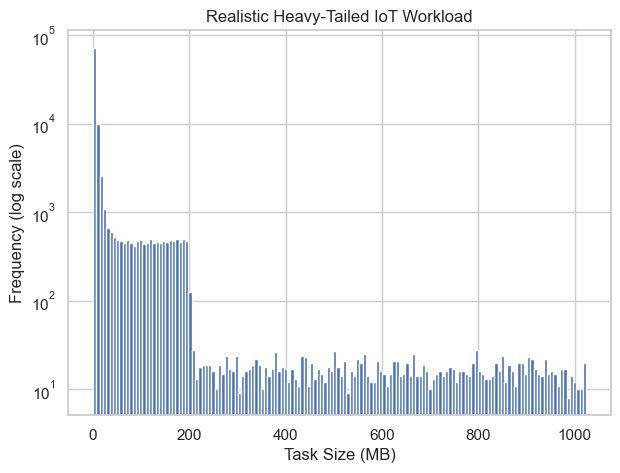

In [220]:
plt.figure(figsize=(7,5))

plt.hist(tasks["task_size_mb"], bins=150)
plt.yscale("log")

plt.title("Realistic Heavy-Tailed IoT Workload")
plt.xlabel("Task Size (MB)")
plt.ylabel("Frequency (log scale)")

plt.show()

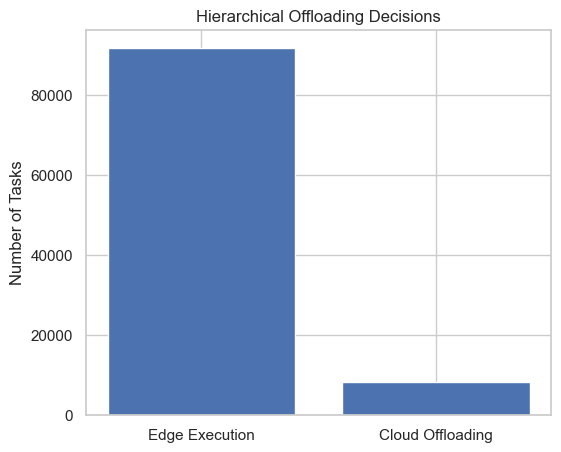

In [221]:
decision_counts = tasks["offload_label"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(["Edge Execution", "Cloud Offloading"],
        decision_counts.values)

plt.title("Hierarchical Offloading Decisions")
plt.ylabel("Number of Tasks")
plt.show()

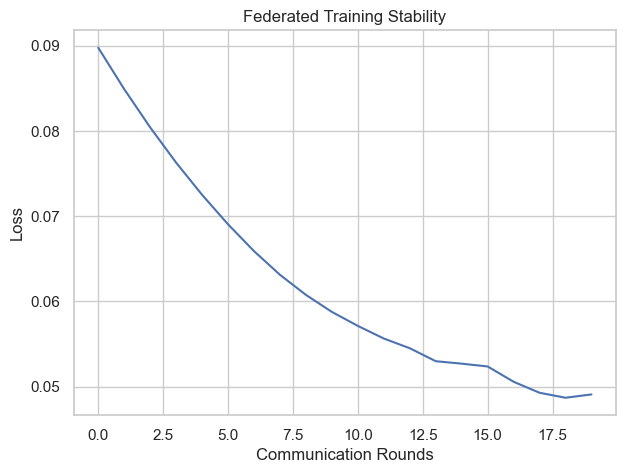

In [222]:
plt.figure(figsize=(7,5))

plt.plot(federated_losses)

plt.title("Federated Training Stability")
plt.xlabel("Communication Rounds")
plt.ylabel("Loss")

plt.show()